# Project 05 – Clinical Trial Disease Category Classification
## Step 02: Model Comparison, Evaluation and Best Model Saving

Models: Logistic Regression, Random Forest, Linear SVM.

In [1]:
import os
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,classification_report,confusion_matrix,ConfusionMatrixDisplay
os.makedirs("model_files",exist_ok=True)

## 1. Load Step 01 Output

In [2]:
df=pd.read_csv("step01_processed_data.csv")
text_col="brief_summary_preprocessed"
target_col="source_condition_query"
df[text_col]=df[text_col].fillna("")
df[target_col]=df[target_col].fillna("Unknown")
print("Data shape:",df.shape)

Data shape: (60337, 21)


## 2. Same Train-Test Split

In [3]:
X_train_text,X_test_text,y_train,y_test=train_test_split(
    df[text_col],df[target_col],test_size=0.20,random_state=42,stratify=df[target_col]
)
print("Training rows:",len(X_train_text))
print("Testing rows:",len(X_test_text))

Training rows: 48269
Testing rows: 12068


## 3. TF-IDF

In [4]:
tfidf=TfidfVectorizer()
X_train_tfidf=tfidf.fit_transform(X_train_text)
X_test_tfidf=tfidf.transform(X_test_text)
print(X_train_tfidf.shape,X_test_tfidf.shape)

(48269, 78911) (12068, 78911)


## 4. Train Three Models

In [5]:
models={
    "Logistic Regression":LogisticRegression(max_iter=1000),
    "Random Forest":RandomForestClassifier(n_estimators=200,random_state=42,n_jobs=-1),
    "Linear SVM":LinearSVC()
}
results=[]
predictions={}
for name,model in models.items():
    print("Training:",name)
    model.fit(X_train_tfidf,y_train)
    pred=model.predict(X_test_tfidf)
    predictions[name]=pred
    results.append({
        "Model":name,
        "Accuracy":accuracy_score(y_test,pred),
        "Precision":precision_score(y_test,pred,average="weighted",zero_division=0),
        "Recall":recall_score(y_test,pred,average="weighted",zero_division=0),
        "F1-Score":f1_score(y_test,pred,average="weighted",zero_division=0)
    })
results_df=pd.DataFrame(results).sort_values("F1-Score",ascending=False).reset_index(drop=True)
display(results_df.round(4))

Training: Logistic Regression
Training: Random Forest
Training: Linear SVM


,Model,Accuracy,Precision,Recall,F1-Score
0,Linear SVM,0.9548,0.9553,0.9548,0.9548
1,Logistic Regression,0.9453,0.9463,0.9453,0.9452
2,Random Forest,0.9354,0.9371,0.9354,0.9351


## 5. Select the Final Model

The final model is selected using the highest weighted F1-Score after actual evaluation.

In [6]:
best_model_name=results_df.loc[0,"Model"]
best_model=models[best_model_name]
print("Selected final model:",best_model_name)

Selected final model: Linear SVM


## 6. Best Model Detailed Evaluation

                                       precision    recall  f1-score   support

                              anxiety       0.91      0.96      0.94      1857
                        breast cancer       0.97      0.97      0.97      3260
chronic obstructive pulmonary disease       0.93      0.91      0.92      1236
                             covid-19       0.98      0.95      0.96      2031
                             glaucoma       0.99      0.96      0.97       435
                 rheumatoid arthritis       0.96      0.93      0.94       727
                   sickle cell anemia       0.99      0.90      0.94       228
                      type 2 diabetes       0.96      0.97      0.96      2294

                             accuracy                           0.95     12068
                            macro avg       0.96      0.94      0.95     12068
                         weighted avg       0.96      0.95      0.95     12068

Confusion Matrix:
[[1787   17   23   12    2    5

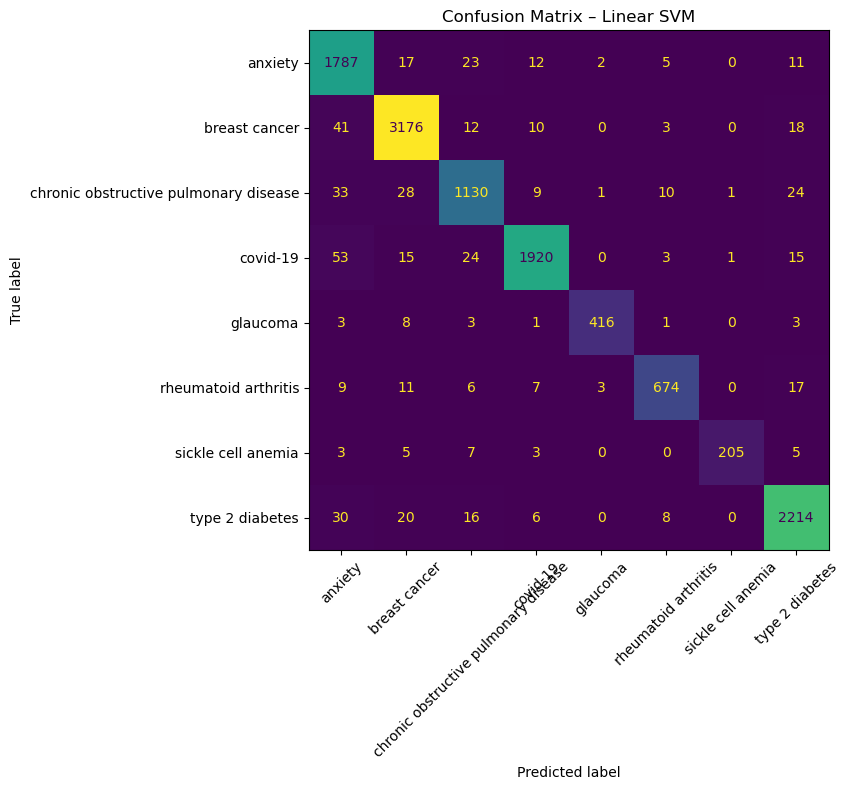

In [7]:
best_pred=predictions[best_model_name]
print(classification_report(y_test,best_pred,zero_division=0))

cm=confusion_matrix(y_test,best_pred)
print("Confusion Matrix:")
print(cm)

disp=ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=best_model.classes_)
fig,ax=plt.subplots(figsize=(10,8))
disp.plot(ax=ax,xticks_rotation=45,colorbar=False)
plt.title(f"Confusion Matrix – {best_model_name}")
plt.tight_layout()
plt.show()

## 7. Save Pickle Files

In [8]:
with open("model_files/best_model.pkl","wb") as f:
    pickle.dump(best_model,f)
with open("model_files/tfidf_vectorizer.pkl","wb") as f:
    pickle.dump(tfidf,f)
print("Saved model_files/best_model.pkl")
print("Saved model_files/tfidf_vectorizer.pkl")

Saved model_files/best_model.pkl
Saved model_files/tfidf_vectorizer.pkl


## Final Output

```text
model_files/
├── best_model.pkl
└── tfidf_vectorizer.pkl
```

`best_model.pkl` is loaded by `app.py`.